In [52]:
import sqlite3

#mss used for screenshotting 
from mss import mss

#Gym used Environment components
import gymnasium as gym
from gymnasium import Env
from gymnasium import spaces

print("all good")

#Imports
#Pytorch used for the neural nets
import torch
import torchvision

#NumPy used for operations (Transformational framework)
import numpy as np

#OpenCV used for frame processing
import cv2

#Matplotlib to visualize captured frames
from matplotlib import pyplot as plt

#time for pauses
import time
from collections import deque

import sys
print(sys.executable)
import torch
print("CUDA Available:", torch.cuda.is_available())
print("PyTorch CUDA Version:", torch.version.cuda)
from pynput.mouse import Controller as MouseController, Button
from pynput.keyboard import Controller as KeyboardController

all good
c:\ProgramData\anaconda3\envs\new_env\python.exe
CUDA Available: True
PyTorch CUDA Version: 11.8


In [53]:
#just combo detection for now

#have an mss screen shot of each respective digit's place taken each frame
#also need the stamps taken from osu
#run template matching with the digit stamps on each respective digitn to figure out the number
# multiply each digit detected with their respective place in the number
# for exmaple the 3 in 1300 would be detected as just a 3, then I just multiply it by 100
# then I can add them up and get the actual combo at each frame step 
# or perhaps I could just detect each digit and then just append them to eachother
#  

(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)


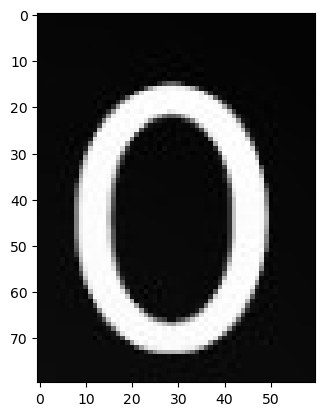

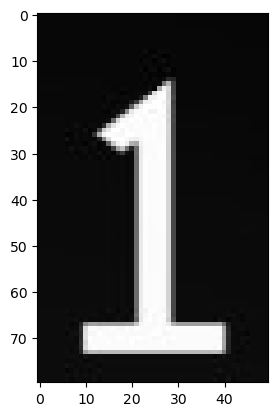

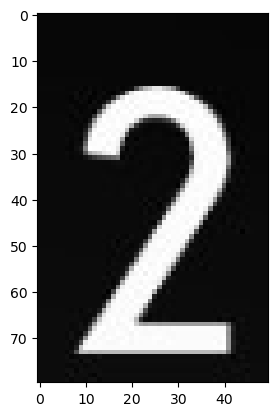

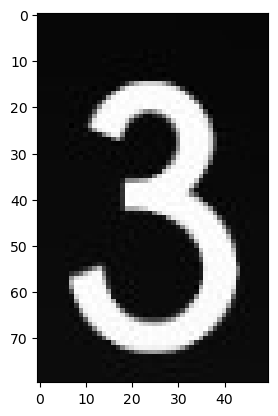

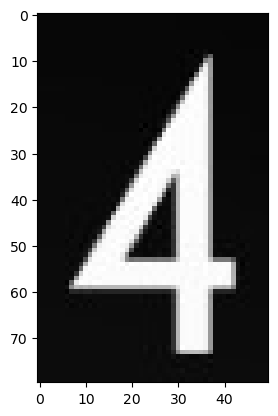

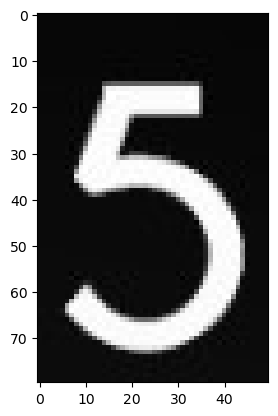

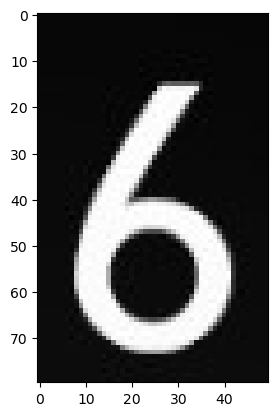

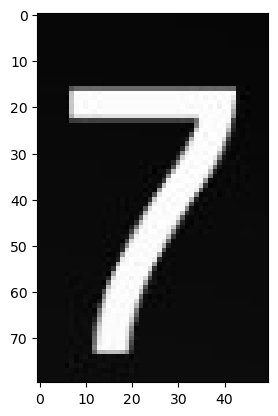

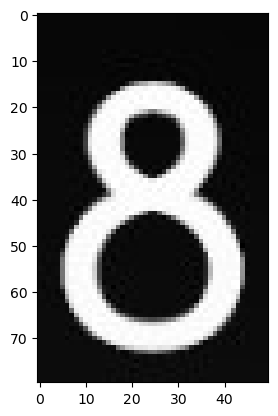

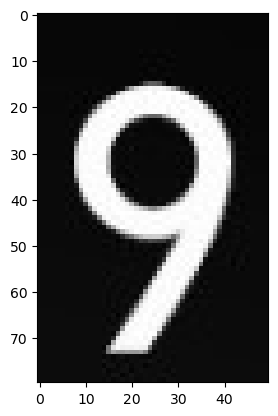

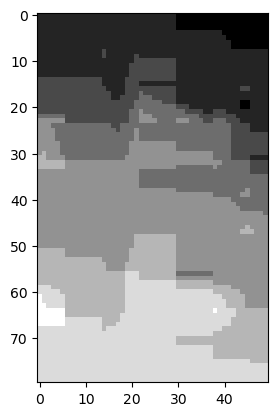

In [78]:
stamp_paths = [
               r"C:\Osu!Conda\digits\one.jpg",
               r"C:\Osu!Conda\digits\two.jpg",
               r"C:\Osu!Conda\digits\three.jpg",
               r"C:\Osu!Conda\digits\four.jpg",
               r"C:\Osu!Conda\digits\five.jpg",
               r"C:\Osu!Conda\digits\six.jpg",
               r"C:\Osu!Conda\digits\seven.jpg",
               r"C:\Osu!Conda\digits\eight.jpg",
               r"C:\Osu!Conda\digits\nine.jpg",
               r"C:\Osu!Conda\digits\background.jpg"]

digit_stamps = ["dih"]

digit_stamps[0] = np.array((cv2.imread(r"C:\Osu!Conda\digits\zero.jpg", cv2.IMREAD_GRAYSCALE)))

for path in stamp_paths: 
    digit_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row, end_row = 1000, 1080
start_col, end_col = 10, 60

digit_stamps[0] = digit_stamps[0][start_row:end_row, start_col+50:end_col+60]

for x in range(1,11):
    digit_stamps[x] = digit_stamps[x][start_row:end_row, start_col:end_col]
    print(digit_stamps[x].shape)

for digit in range(0,11):
    plt.imshow(digit_stamps[digit], cmap='gray')
    time.sleep(0.5)
    plt.show()

In [ ]:
percent_stamp_paths = [
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\blank.jpg",
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\one.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\two.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\three.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\four.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\five.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\six.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\seven.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\eight.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\nine.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\zero.jpg"]

percent_stamps = []

for path in percent_stamp_paths: 
    percent_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row2, end_row2 = 55, 80
start_col2, end_col2 = 1812, 1826
offset=17

percent_stamps[0] = percent_stamps[0][start_row2:end_row2, start_col2-offset:end_col2-offset]
percent_stamps[1] = percent_stamps[1][start_row2:end_row2, start_col2-offset-8:end_col2-offset-8]

plt.imshow(percent_stamps[0], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[0].shape)

plt.imshow(percent_stamps[1], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[1].shape)

for x in range(2, 11):
    percent_stamps[x] = percent_stamps[x][start_row2:end_row2, start_col2:end_col2]
    print(percent_stamps[x].shape)

for percent in range(2,11):
    plt.imshow(percent_stamps[percent], cmap='gray')
    time.sleep(0.05)
    plt.show()

In [79]:
def digit_frames():
    with mss() as sct:
        digit_screen1_area = {"top":start_row,"left":start_col,"width":55,"height":80}
        digit_screen2_area = {"top":start_row,"left":start_col+55,"width":55,"height":80}
        digit_screen3_area = {"top":start_row,"left":start_col+110,"width":55,"height":80}
        digit_screen4_area = {"top":start_row,"left":start_col+163,"width":55,"height":80}

        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(digit_screen1_area)
        r2 = sct.grab(digit_screen2_area)
        r3 = sct.grab(digit_screen3_area)
        r4 = sct.grab(digit_screen4_area)

        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        r_3_np = np.array(r3)
        r_4_np = np.array(r4)
        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)

        retry_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4)
        return retry_bounds
    
top = 55
left = 1810-3
width = 14
height = 25
off_set = 16

def percent_frames():
    with mss() as sct:
        digit_screen1_area = {"top":top,"left":left-20,"width":width,"height":height}
        digit_screen2_area = {"top":top,"left":left+off_set-11,"width":width,"height":height}
        digit_screen3_area = {"top":top,"left":left+off_set*2-3,"width":width,"height":height}
        digit_screen4_area = {"top":top,"left":left+off_set*3+6,"width":width,"height":height}
        digit_screen5_area = {"top":top,"left":left+off_set*4+14,"width":width,"height":height}

        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(digit_screen1_area)
        r2 = sct.grab(digit_screen2_area)
        r3 = sct.grab(digit_screen3_area)
        r4 = sct.grab(digit_screen4_area)
        r5 = sct.grab(digit_screen5_area)

        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        r_3_np = np.array(r3)
        r_4_np = np.array(r4)
        r_5_np = np.array(r5)

        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)
        digits_box_5 = cv2.cvtColor(r_5_np, cv2.COLOR_BGR2GRAY)

        percent_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4,digits_box_5)
        return percent_bounds

In [57]:
def verify_8_vs_3(digit_crop):
    """
    Scans horizontally at y=6 and y=16.
    An '8' should have 2 crossings (walls) at these heights.
    A '3' should only have 1 crossing (the right wall).
    """
    # 1. Ensure the image is grayscale for intensity checking
    if len(digit_crop.shape) == 3:
        digit_crop = cv2.cvtColor(digit_crop, cv2.COLOR_BGR2GRAY)

    def count_horizontal_crossings(y_level):
        crossings = 0
        in_white_zone = False
        # Scan x from 0 to 14
        for x in range(14):
            # Threshold: 140-160 is usually the "sweet spot" for osu! text core
            # It ignores the faint gray 'glow' and hit-bursts
            pixel_intensity = digit_crop[y_level, x]
            
            if pixel_intensity > 150: # We hit a 'white' area
                if not in_white_zone:
                    crossings += 1
                    in_white_zone = True
            else: # We are in a 'black' area
                in_white_zone = False
        return crossings

    # Check top loop and bottom loop
    # We check a small range (y-1 to y+1) to be safe against slight italics/bouncing
    top_crossings = max(count_horizontal_crossings(y) for y in [5, 6, 7])
    bot_crossings = max(count_horizontal_crossings(y) for y in [15, 16, 17])

    # LOGIC: If the top part has two walls (left and right), it's an 8.
    # If it only has one wall (right), the left side is open, so it's a 3.
    if top_crossings >= 2:
        return 8
    else:
        return 3

In [ ]:
import time
#testing cell for the percentage numbers
time.sleep(2)
for x in range(5):
    time.sleep(1)
    digit_1, digit_2, digit_3, digit_4, digit_5, = percent_frames()
    print("digit 1")
    plt.imshow(digit_1, cmap='gray')
    plt.show()
    print("digit 2")
    plt.imshow(digit_2, cmap='gray')
    plt.show()
    print("digit 3")
    plt.imshow(digit_3, cmap='gray')
    plt.show()
    print("digit 4")
    plt.imshow(digit_4, cmap='gray')
    plt.show()
    print("digit 5")
    plt.imshow(digit_5, cmap='gray')
    plt.show()

In [59]:
#percent numbers template matching testing
def percent_frames_read():
    percents = percent_frames()

    for digit_box in percents:
        #check aganst each stamp loop
        plt.imshow(digit_box, cmap='gray')
        plt.title(f"digit_box")
        plt.show()
        i=0
        for stamp in percent_stamps:
            similarity_map = cv2.matchTemplate(digit_box, stamp, cv2.TM_CCOEFF_NORMED)
            _, max_val, _, _ = cv2.minMaxLoc(similarity_map)
            print(f"Best Match Score for index {i}: {max_val}")
            i = i+1


In [ ]:
#testing cell for percent_frames logs
time.sleep(5)
for x in range(100):
    percent_frames_read()
    time.sleep(0.016)


digit 1


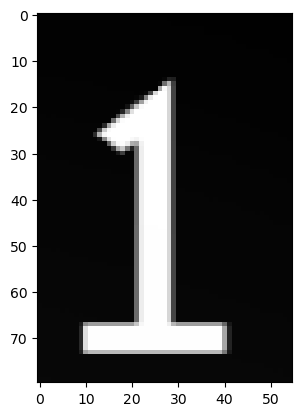

digit 2


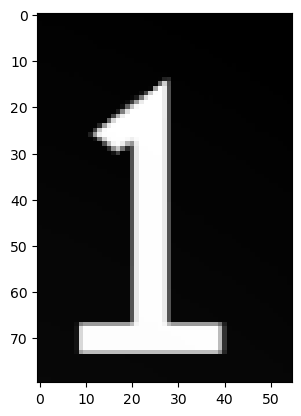

digit 3


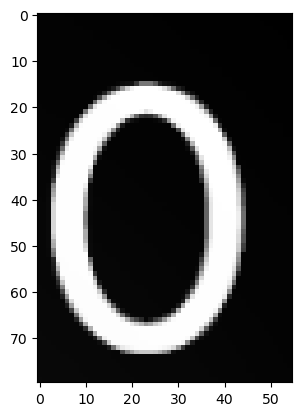

digit 4


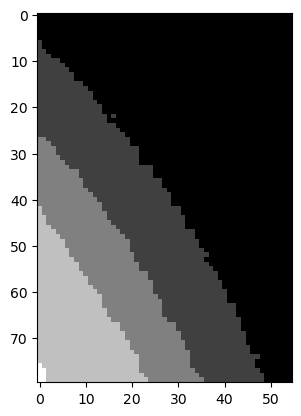

digit 1


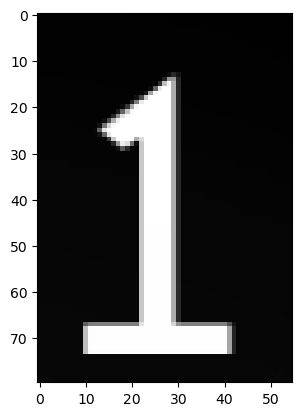

digit 2


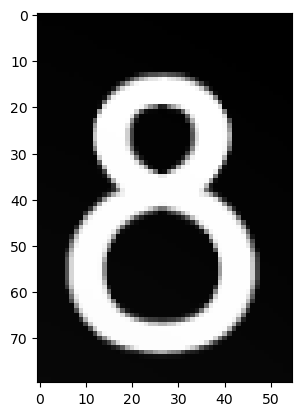

digit 3


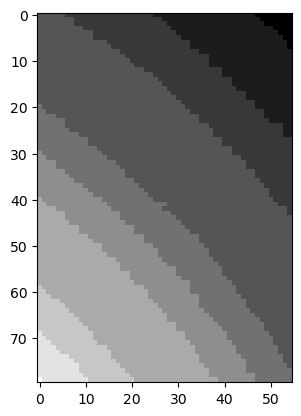

digit 4


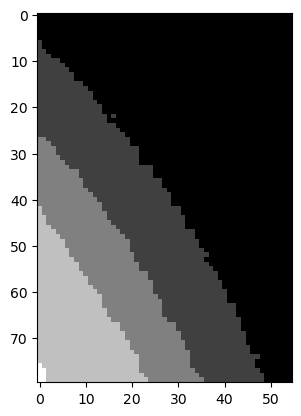

digit 1


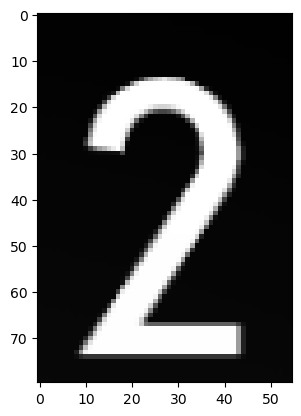

digit 2


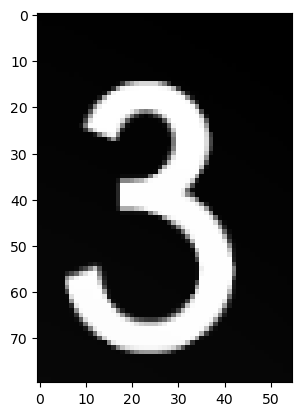

digit 3


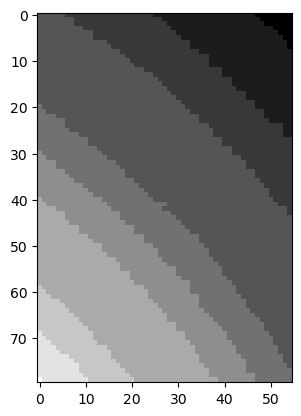

digit 4


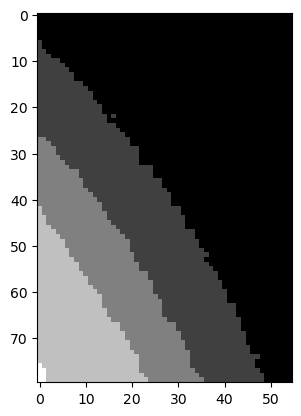

In [70]:
#testing cell for the combo numbers
for x in range(3):
    time.sleep(2)
    digit_1, digit_2, digit_3, digit_4 = digit_frames()
    print("digit 1")
    plt.imshow(digit_1, cmap='gray')
    plt.show()
    time.sleep(.5)
    print("digit 2")
    plt.imshow(digit_2, cmap='gray')
    plt.show()
    print("digit 3")
    plt.imshow(digit_3, cmap='gray')
    plt.show()
    print("digit 4")
    time.sleep(.5)
    plt.imshow(digit_4, cmap='gray')
    plt.show()

In [87]:
import cv2
import time

# =========================
# SETTINGS 
# =========================
BACKGROUND_INDEX = 10
MIN_ACCEPT_SCORE = 0.8
MAX_FORWARD_JUMP = 25
MIN_MARGIN = 0.08

# Break handling
BREAK_LANDS_AT_OR_BELOW = 1
BREAK_CONFIRM_FRAMES = 2
BREAK_STRICT_CONF = 0.85

# Transition handling
ROLLOVER_TOLERANCE = 3
ROLLOVER_MAX_OVERSHOOT = 15

# NEW: anti-stuck / history + latch
HIST_LEN = 6
BREAK_LATCH_MS = 200               # Allow backwards updates briefly after break
BIG_DROP_RATIO = 0.7               # If RAW < 60% of STABLE, it's a break
BIG_DROP_MIN = 8                   # Or if RAW is 8 digits lower than STABLE
ALLOW_BACKWARDS_DURING_LATCH = True
APPEND_ZERO_REJECT = True          # Reject stable->stable*10 (9->90)
APPEND_ZERO_CONF_MIN = 0.75 

# =========================
# STATE (persists across calls)
# =========================
last_good_combo = 0
break_streak = 0
raw_hist = []                      # List of tuples (raw, conf)
break_latch_until = 0.0

# =========================
# HELPERS
# =========================
def num_digits(n: int) -> int:
    return 1 if n == 0 else len(str(n))

def expected_rollover(prev: int) -> int:
    d = num_digits(prev)
    return 10 ** d

def is_plausible_rollover(prev: int, raw: int) -> bool:
    exp = expected_rollover(prev)
    if exp <= raw <= exp + ROLLOVER_TOLERANCE:
        return True
    if exp <= raw <= exp + ROLLOVER_MAX_OVERSHOOT:
        return True
    return False

def push_hist(raw, conf):
    global raw_hist
    raw_hist.append((raw, conf))
    if len(raw_hist) > HIST_LEN:
        raw_hist.pop(0)

def count_break_like(stable_now: int):
    """
    Catches breaks even when combo doesn't drop to 0/1.
    """
    tiny = 0
    bigdrop = 0
    for r, c in raw_hist:
        if c >= BREAK_STRICT_CONF:
            # 1. Check for resets to near-zero
            if r <= BREAK_LANDS_AT_OR_BELOW:
                tiny += 1
            
            # 2. Check for significant downward jumps
            if stable_now > r:
                is_significant = (
                    (stable_now - r >= BIG_DROP_MIN) or 
                    (r <= stable_now * BIG_DROP_RATIO) or
                    (stable_now < 10 and r < stable_now) # Fixes "stuck at 9"
                )
                if is_significant:
                    bigdrop += 1
                    
    return tiny, bigdrop

# =========================
# READ ONE FRAME OF COMBO
# =========================
def read_combo_once():
    global last_good_combo, break_streak, break_latch_until

    digits = digit_frames()
    recognized_digits = []
    digit_scores = []

    # 1. PER-SPOT TEMPLATE MATCHING
    for x in range(4):
        best_match_index = None
        best_match_score = -1.0
        second_best_score = -1.0

        for y in range(11):
            similarity_map = cv2.matchTemplate(digits[x], digit_stamps[y], cv2.TM_CCOEFF_NORMED)
            _, max_val, _, _ = cv2.minMaxLoc(similarity_map)
            if max_val > best_match_score:
                second_best_score = best_match_score
                best_match_score = float(max_val)
                best_match_index = y
            elif max_val > second_best_score:
                second_best_score = float(max_val)

        match_margin = best_match_score - second_best_score
        if best_match_index != BACKGROUND_INDEX and match_margin < MIN_MARGIN:
            recognized_digits = []
            break
        if best_match_index == BACKGROUND_INDEX:
            break
        recognized_digits.append(best_match_index)
        digit_scores.append(best_match_score)

    # 2. BUILD RAW COMBO + CONF
    if not recognized_digits:
        raw_combo = 0
        confidence = 0.0
    else:
        raw_combo = int("".join(str(d) for d in recognized_digits))
        confidence = float(min(digit_scores))

    if len(recognized_digits) >= 2 and all(d == 0 for d in recognized_digits):
        confidence = 0.0

    push_hist(raw_combo, confidence)

    # 3. FILTER INTO STABLE COMBO
    stable_combo = last_good_combo
    accepted = False
    reason = "kept_last"
    now = time.perf_counter()
    in_latch = now < break_latch_until

    if confidence < MIN_ACCEPT_SCORE:
        reason = "low_conf"
    else:
        # A. Appended Zero Reject (e.g., 9 -> 90)
        if (APPEND_ZERO_REJECT and confidence >= APPEND_ZERO_CONF_MIN and 
            last_good_combo >= 1 and raw_combo == last_good_combo * 10):
            reason = "append0_rejected"
        
        # B. Same Value
        elif raw_combo == last_good_combo:
            accepted = True
            reason = "same"
        
        # C. Forward Movement (The Logic Fix)
        elif raw_combo > last_good_combo:
            jump = raw_combo - last_good_combo
            
            # If jump is small, we don't care about digit counts
            if jump <= MAX_FORWARD_JUMP:
                stable_combo = raw_combo
                accepted = True
                reason = "forward_ok"
            # If jump is big, only allow if it's a plausible rollover (e.g. 99 -> 105)
            elif is_plausible_rollover(last_good_combo, raw_combo):
                stable_combo = raw_combo
                accepted = True
                reason = "digits_increased_rollover_ok"
            else:
                reason = "forward_jump_rejected"

        # D. Backwards Movement (Breaks)
        else:
            if ALLOW_BACKWARDS_DURING_LATCH and in_latch:
                stable_combo = raw_combo
                accepted = True
                reason = "backwards_allowed_in_latch"
            else:
                tiny_cnt, bigdrop_cnt = count_break_like(last_good_combo)
                break_confirmed = (tiny_cnt >= BREAK_CONFIRM_FRAMES) or (bigdrop_cnt >= BREAK_CONFIRM_FRAMES)

                if break_confirmed:
                    stable_combo = raw_combo
                    accepted = True
                    reason = "combo_break(hist_confirmed)"
                    break_latch_until = now + (BREAK_LATCH_MS / 1000.0)
                elif (raw_combo <= BREAK_LANDS_AT_OR_BELOW and 
                      last_good_combo > BREAK_LANDS_AT_OR_BELOW and 
                      confidence >= 0.95):
                    stable_combo = raw_combo
                    accepted = True
                    reason = "combo_break(instant_reset)"
                    break_latch_until = now + (BREAK_LATCH_MS / 1000.0)
                else:
                    reason = "backwards_ignored"

    if accepted:
        last_good_combo = stable_combo

    print(f"RAW={raw_combo:4d} CONF={confidence:.2f} STABLE={stable_combo:4d} [{reason}]")
    return stable_combo

In [92]:
# --- GLOBAL STATE (Initialize these once at the top of your script) ---
accuracy_settle_buffer = []
SETTLING_FRAME_TARGET = 1
total_frames_processed = 0

# --- Accuracy Settings ---
ACCURACY_CONFIDENCE_THRESHOLD = 0.6

def read_accuracy_once(previous_accuracy_value):
    global accuracy_settle_buffer
    global last_stable_val, waiting_val, total_frames_processed
    """
    Reads the 5-digit accuracy display, converts it to a float, 
    and waits for the value to 'settle' to filter out UI animations.
    """
    
    # 1. Capture and match digits
    digit_box_crops = percent_frames() 
    detected_digits = []
    match_confidences = []

    for i, crop in enumerate(digit_box_crops):
        best_match_index = -1
        highest_similarity_score = -1.0
        
        for stamp_index, stamp_image in enumerate(percent_stamps):
            result_map = cv2.matchTemplate(crop, stamp_image, cv2.TM_CCOEFF_NORMED)
            _, max_similarity, _, _ = cv2.minMaxLoc(result_map)
            
            if max_similarity > highest_similarity_score:
                highest_similarity_score = max_similarity
                best_match_index = stamp_index
        
        if best_match_index == 0: 
            detected_digits.append(None)
        elif best_match_index == 10: 
            detected_digits.append(0)
        else: 
            detected_digits.append(best_match_index)
        match_confidences.append(highest_similarity_score)

    # 2. Position-based math
    try:
        hundreds_val   = detected_digits[0] if detected_digits[0] is not None else 0
        tens_val       = detected_digits[1] if detected_digits[1] is not None else 0
        ones_val       = detected_digits[2] if detected_digits[2] is not None else 0
        tenths_val     = detected_digits[3] if detected_digits[3] is not None else 0
        hundredths_val = detected_digits[4] if detected_digits[4] is not None else 0
        
        calculated_accuracy = (
            (hundreds_val * 100) + (tens_val * 10) + (ones_val * 1) + 
            (tenths_val * 0.1) + (hundredths_val * 0.01)
        )
        average_match_confidence = sum(match_confidences) / 5
        print(average_match_confidence)
    except Exception as error:
        print(f"Error calculating accuracy: {error}")
        return previous_accuracy_value

    # --- SAFETY & SETTLING FILTERS ---
    
    # Filter 1: Confidence
    if average_match_confidence < ACCURACY_CONFIDENCE_THRESHOLD:
        return previous_accuracy_value 

    # Filter 2: Max Value
    if calculated_accuracy > 100.0:
        calculated_accuracy = 100.0

    # --- GLOBAL STATE (Put these at the very top of your script) ---
    # last_stable_val = 0.0
    # waiting_val = None
    # total_frames_processed = 0

    total_frames_processed += 1

    # 1. Calculate Dynamic Leeway
    if total_frames_processed < 251:
        trust_threshold = 100 #Massive leeway for early game nuance
    elif total_frames_processed < 700:
        # Gradually tightens: 
        trust_threshold = 100*((250/total_frames_processed))**2.5
    else:
        trust_threshold = 5
    # 2. Flicker Gate Logic
    diff = abs(calculated_accuracy - last_stable_val)

    if diff > trust_threshold:
        if waiting_val is not None and abs(calculated_accuracy - waiting_val) < 0.05:
            # This is the 2nd frame in a row showing this big change.
            # It's not a flicker, it's real nuance! Update now.
            last_stable_val = calculated_accuracy
            waiting_val = None
        else:
            # Possible flicker detected. Put in waiting room, return old value.
            waiting_val = calculated_accuracy
            return previous_accuracy_value
    else:
        # Small change, update normally
        last_stable_val = calculated_accuracy
        waiting_val = None

    return last_stable_val

In [ ]:
#percent testing in game: 
import time
last_stable_val = 100.0  # Start at 100%
waiting_val = None
total_frames_processed = 0
accuracy_settle_buffer = [] # You can keep this if you want, but the new gate replaces its job
# --- INITIAL STATE ---
# We start at 100.0 because that is how every song begins
current_accuracy = 100.0
frame_count = 0

print("--- ACCURACY OCR TEST STARTING ---")
print("Switch to the game window now! Testing starts in 5 seconds...")
time.sleep(5)

try:
    while True:
        start_time = time.perf_counter()
        
        # 1. Capture the frame and calculate the new accuracy
        # We pass 'current_accuracy' so the function can compare the new read to the old one
        new_read = read_accuracy_once(current_accuracy)
        
        # 2. Update our tracker
        current_accuracy = new_read
        frame_count += 1
        
        # 3. Print the debug line
        # Every 3 frames (~20 times a second) to avoid spamming the console too hard
        if frame_count % 3 == 0:
            print(f"FRAME: {frame_count:05d} | ACCURACY: {current_accuracy:6.2f}%")

        # 4. Maintain timing
        # Aiming for ~60Hz (0.016s). We subtract the time the OCR took to keep it steady.
        elapsed = time.perf_counter() - start_time
        sleep_time = max(0, 0.016 - elapsed)
        time.sleep(sleep_time)

except KeyboardInterrupt:
    print("\n--- TEST TERMINATED BY USER ---")
    print(f"Final Accuracy Recorded: {current_accuracy}%")

In [94]:
#combo testing in game
time.sleep(5)
for x in range(500):
    read_combo_once()



RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [low_conf]
RAW=   0 CONF=0.00 STABLE=   0 [lo